In [2]:
# imports:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.optim.lr_scheduler import StepLR
import nibabel as nib
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt


## Pre-Procesamiento

In [4]:
def normalize(img):
    """Normalizes a numpy image array to [0,1]

    Args:
        img: Image array
    """
    img = img.astype(np.float32)
    return (img - img.min()) / (img.max() - img.min() + 1e-8)

def save_slice(slice_array, path, as_png=True):
    """Saves the slice either as a PNG or numpy file

    Args:
        slice_array: Array to save
        path: Path the slices should be saved to
        as_png: Set whether to save as PNG or not
    """
    if as_png:
        im = Image.fromarray((slice_array * 255).astype(np.uint8))
        im.save(path)
    else:
        np.save(path, slice_array)

def extract_slices(image_dir, label_dir, out_img_dir, out_lbl_dir, axis=0, as_png=False):
    """
    Args:
        image_dir: Directory with 3D images (.nii.gz)
        label_dir: Directory with corresponding labels (.nii.gz)
        out_img_dir: Directory to save 2D image slices
        out_lbl_dir: Directory to save corresponding labels
        axis: Axis along which to slice (0=sagittal, 1=coronal, 2=axial)
        as_png: Set whether to save as PNG or not
    """
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".nii.gz")])


    for f in tqdm(image_files, desc="Processing volumes"):
        img_path = os.path.join(image_dir, f)
        lbl_path = os.path.join(label_dir, f)

        if not os.path.exists(lbl_path):
            continue

        # Load 3D volumes
        img = nib.load(img_path).get_fdata()
        lbl = nib.load(lbl_path).get_fdata().astype(np.uint8)
        lbl = (lbl > 0).astype(np.uint8)

        # Remove 4th dimension if present
        if img.ndim == 4:
            img = img[..., 0]
        if lbl.ndim == 4:
            lbl = lbl[..., 0] 

        img = normalize(img)  

        if img.shape != lbl.shape:
            print(f"Image and Label mismatch: {img.shape} vs {lbl.shape}")
            continue

        # Move axis to first dimension
        img = np.moveaxis(img, axis, 0)
        lbl = np.moveaxis(lbl, axis, 0)

        # Process slices
        for i in range(img.shape[0]):
            img_slice = img[i]
            lbl_slice = lbl[i]
            
            if img_slice.shape != (320,320):
                print(f"Invalid slice shape: slice {i} of {f} shape: {img_slice.shape}")
                continue
            
            # Ensure consistent naming
            name = f.replace(".nii.gz", f"_slice_{i:03d}")
            save_slice(img_slice, os.path.join(out_img_dir, name + (".png" if as_png else ".npy")), as_png)
            save_slice(lbl_slice, os.path.join(out_lbl_dir, name + (".png" if as_png else ".npy")), as_png)

if __name__ == "__main__":
    extract_slices(
        image_dir="Data/Task05_Prostate/imagesTr",        
        label_dir="Data/Task05_Prostate/labelsTr",        
        out_img_dir="Data/prostate_train/images",  
        out_lbl_dir="Data/prostate_train/labels",  
        axis=2, #axial
        as_png=False
    )
     

Processing volumes:  36%|███▋      | 12/33 [00:02<00:04,  4.80it/s]

Invalid slice shape: slice 0 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 1 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 2 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 3 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 4 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 5 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 6 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 7 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 8 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 9 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 10 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 11 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 12 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 13 of prostate_18.nii.gz shape: (256, 256)
Invalid slice shape: slice 14 

Processing volumes:  55%|█████▍    | 18/33 [00:03<00:02,  5.64it/s]

Invalid slice shape: slice 0 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 1 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 2 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 3 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 4 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 5 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 6 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 7 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 8 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 9 of prostate_28.nii.gz shape: (384, 384)
Invalid slice shape: slice 10 of prostate_28.nii.gz shape: (384, 384)


Processing volumes:  70%|██████▉   | 23/33 [00:05<00:02,  3.43it/s]

Invalid slice shape: slice 0 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 1 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 2 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 3 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 4 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 5 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 6 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 7 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 8 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 9 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 10 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 11 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 12 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 13 of prostate_37.nii.gz shape: (256, 256)
Invalid slice shape: slice 14 

Processing volumes:  82%|████████▏ | 27/33 [00:06<00:01,  3.61it/s]

Invalid slice shape: slice 0 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 1 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 2 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 3 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 4 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 5 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 6 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 7 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 8 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 9 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 10 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 11 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 12 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 13 of prostate_41.nii.gz shape: (256, 256)
Invalid slice shape: slice 14 

Processing volumes: 100%|██████████| 33/33 [00:07<00:00,  4.32it/s]


## Dataloader

In [3]:
class SliceDataset(Dataset):
    """Pytorch Dataset for loading preprocessed 2D slices"""
    def __init__(self, image_dir, label_dir):
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(".npy")])
        self.image_dir = image_dir
        self.label_dir = label_dir

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        fname = self.image_files[idx]
        img = np.load(os.path.join(self.image_dir, fname))
        lbl = np.load(os.path.join(self.label_dir, fname))
        
        assert img.shape == lbl.shape, f"Shape mismatch in {fname}: {img.shape} vs {lbl.shape}"
        assert img.shape == (320, 320), f"Unexpected slice size in {fname}: {img.shape}"

        img = torch.from_numpy(img).unsqueeze(0).float()
        lbl = torch.from_numpy(lbl).unsqueeze(0).float()

        return img, lbl

In [4]:
dataset = SliceDataset("Data/prostate_train/images", "Data/prostate_train/labels")

In [5]:
len(dataset)

540

In [6]:
def visualizar_slice(dataset, idx, alpha=0.4, cmap_mask="jet"):
    """
    Visualiza un slice de imagen y su máscara lado a lado, 
    y además muestra la máscara superpuesta sobre la imagen.
    """
    # Obtener el ítem del dataset
    img_tensor, lbl_tensor = dataset[idx]
    
    # PyTorch usa (C, H, W). Para graficar con matplotlib necesitamos (H, W)
    # Removemos la dimensión del canal usando .squeeze()
    img = img_tensor.squeeze().numpy()
    lbl = lbl_tensor.squeeze().numpy()
    
    # Configurar la figura (3 columnas: Imagen, Máscara, Superposición)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Imagen Original
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title(f"Slice {idx} - Imagen")
    axes[0].axis("off")
    
    # 2. Máscara Sola
    axes[1].imshow(lbl, cmap="gray")
    axes[1].set_title("Máscara (Label)")
    axes[1].axis("off")
    
    # 3. Superposición (Overlay)
    axes[2].imshow(img, cmap="gray")
    # Enmascaramos los ceros de la etiqueta para que el fondo sea transparente
    lbl_masked = np.ma.masked_where(lbl == 0, lbl)
    axes[2].imshow(lbl_masked, cmap=cmap_mask, alpha=alpha)
    axes[2].set_title("Superposición")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

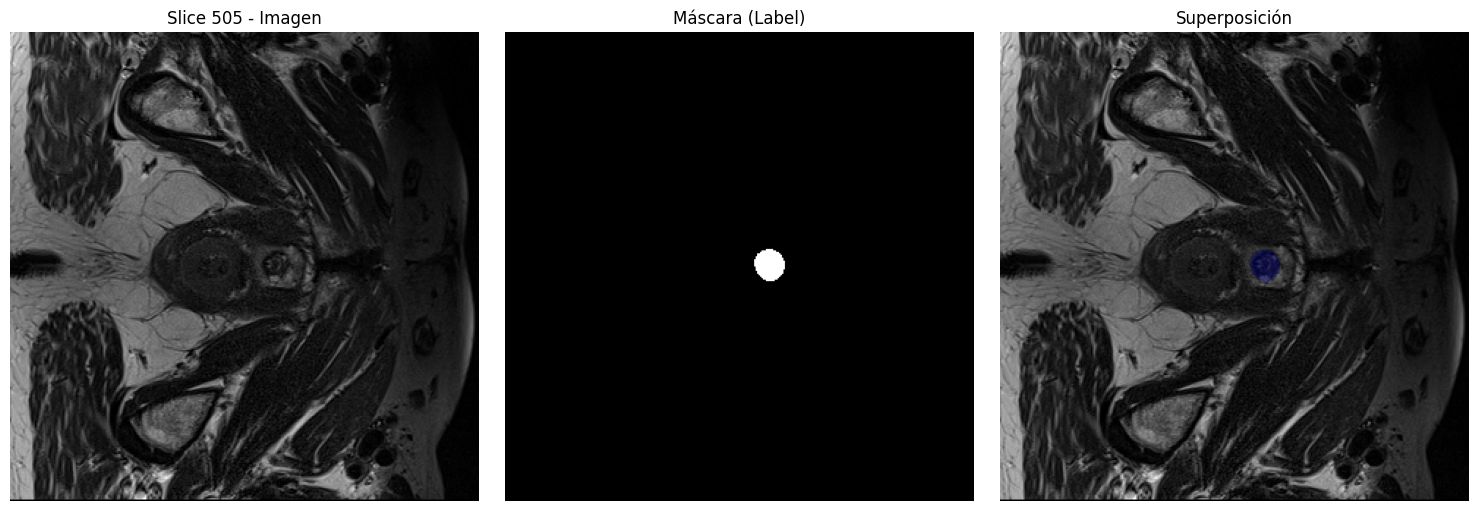

In [7]:
visualizar_slice(dataset, idx=505, alpha=0.4, cmap_mask="jet")

In [8]:
img_tensor, lbl_tensor = dataset[0]

In [9]:
lbl_tensor[0,150:200,150:200]

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])

In [10]:
## un codigo rapido para borrar instancias vacias
# Asumiendo que 'mis_datos' es tu objeto SliceDataset ya definido:
# mis_datos = SliceDataset(image_dir="...", label_dir="...")

print(f"Cantidad inicial de slices: {len(dataset.image_files)}")

# 1. Crear una nueva lista con los archivos que sí contienen etiquetas
archivos_limpios = []

for fname in dataset.image_files:
    # Construimos la ruta usando la carpeta guardada en el dataset
    lbl_path = os.path.join(dataset.label_dir, fname)
    lbl = np.load(lbl_path)
    
    # Si tiene contenido, guardamos el nombre del archivo
    if np.mean(lbl) > 0:
        archivos_limpios.append(fname)

# 2. Reemplazar la lista interna del dataset por la lista filtrada
dataset.image_files = archivos_limpios

print(f"Cantidad final de slices (limpios): {len(dataset.image_files)}")

Cantidad inicial de slices: 540
Cantidad final de slices (limpios): 417


In [13]:
## ahora definimos un dataloader
## dataloader
batch_size = 4 # Ajusta según tu memoria de video (VRAM)

prostate_train_loader = DataLoader(
    dataset, 
    batch_size=batch_size, 
    shuffle=True,      
    #num_workers=2,     # Acelera la carga de datos
    #pin_memory=True    # Mejora velocidad de transferencia a GPU
)

In [14]:
def visualizar_batch(dataloader, alpha=0.4, cmap_mask="jet", batch_idx=0):
    """
    Toma el primer batch de un DataLoader y visualiza uno de sus slices
    junto a su máscara y la superposición.
    """
    # Extraer el primer batch del DataLoader
    images, labels = next(iter(dataloader))
    
    # Verificar que el índice solicitado esté dentro del tamaño del batch
    batch_size = images.shape[0]
    if batch_idx >= batch_size:
        print(f"Error: El batch solo tiene {batch_size} elementos. Usando el índice 0.")
        batch_idx = 0
        
    # Extraer el slice específico y remover las dimensiones extras (B y C)
    # Pasamos de (B, C, H, W) -> (H, W) usando .squeeze() tras indexar
    img = images[batch_idx].squeeze().numpy()
    lbl = labels[batch_idx].squeeze().numpy()
    
    # Configurar la figura de Matplotlib
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # 1. Imagen Original
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title(f"Batch Item {batch_idx} - Imagen")
    axes[0].axis("off")
    
    # 2. Máscara Sola
    axes[1].imshow(lbl, cmap="gray")
    axes[1].set_title("Máscara (Label)")
    axes[1].axis("off")
    
    # 3. Superposición (Overlay)
    axes[2].imshow(img, cmap="gray")
    # Enmascaramos los ceros para mantener la transparencia en el fondo
    lbl_masked = np.ma.masked_where(lbl == 0, lbl)
    axes[2].imshow(lbl_masked, cmap=cmap_mask, alpha=alpha)
    axes[2].set_title("Superposición")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

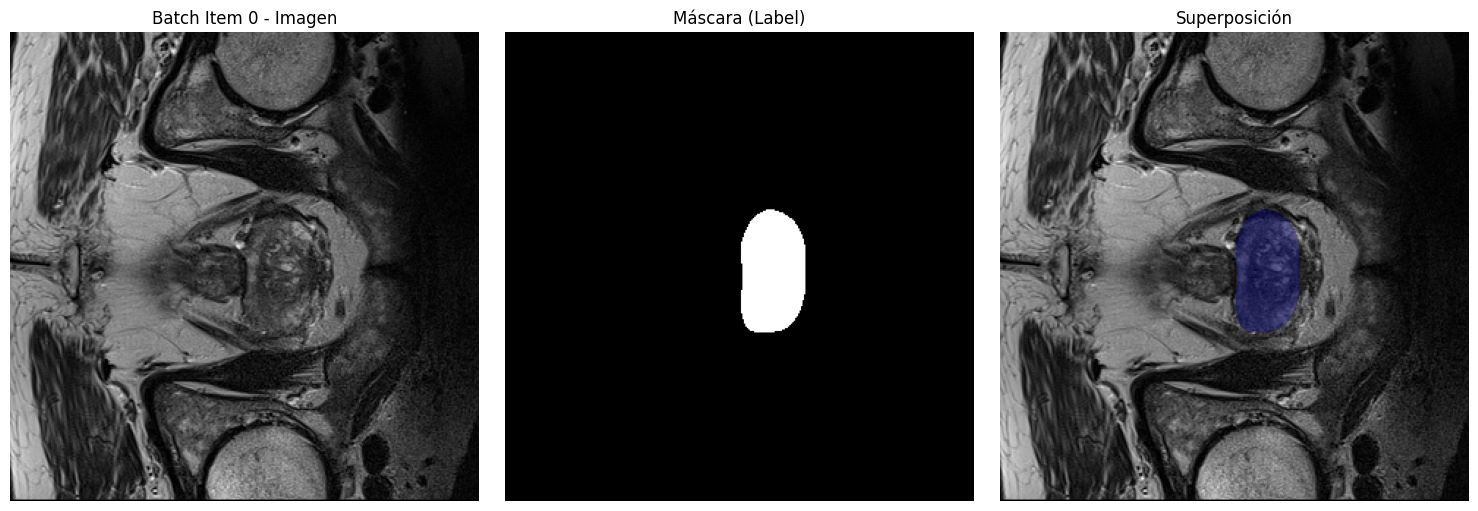

In [15]:
visualizar_batch(prostate_train_loader, alpha=0.4, cmap_mask="jet", batch_idx=0)

In [16]:
len(prostate_train_loader)

105

In [17]:
## Ya tenemos los datos en el formato deseado importaremos los modelos y probaremos un entrenamiento  
img, label = dataset[0]

In [18]:
label.shape

torch.Size([1, 320, 320])

In [19]:
## definimos las funciones de perdida y metricas

def dice_loss(pred, target, smooth=1e-5):
    """Dice loss for segmentation"""
    pred = torch.sigmoid(pred)
    pred = torch.flatten(pred)
    target = torch.flatten(target)
    intersect = (pred * target).sum()
    dice = (2 * intersect + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice

def dice_score(pred, target, smooth=1e-5):
    """Dice coefficient metric"""
    pred = torch.sigmoid(pred)
    pred = torch.flatten(pred > 0.5).float()
    target = torch.flatten(target)
    intersect = (pred * target).sum()
    score = (2 * intersect + smooth) / (pred.sum() + target.sum() + smooth)
    return score

def bce_loss(pred, target):
    """Binary cross-entropy loss"""
    return F.binary_cross_entropy_with_logits(pred, target)

In [20]:
from src import model as models

In [21]:
## defininimos los parametros

# 1. Configuración de Canales (Flujo Simétrico de Dimensiones)
CHANNELS_IN       = 1   # Imágenes RGB de entrada
CHANNELS_LEVEL_1  = 32  # Resolución alta (Skip Connection c1_out / d2_out)
CHANNELS_LEVEL_2  = 64  # Resolución intermedia (Salida de compresión y Pass-Through)
CHANNELS_LATENT   = 32  # Cuello de botella latente (Espacio del ADN / Entrada del NCA)
CHANNELS_OUT      = 1   # Clases del label

# 2. Parámetros de Convolución Estándar
KERNEL_STD        = 3
STRIDE_NORMAL     = 1
STRIDE_COMPRESS   = 2
PADDING_STD       = 1

# 3. Regularización y Normalización
DROPOUT_ENCODER   = 0.1
DROPOUT_DECODER   = 0.0
ACT_RELU          = 'relu'
ACT_NONE          = None


## DICCIONARIO DE PARÁMETROS CONFIGURADO CON VARIABLES COMUNES


params_encoder = {
    'in_c': CHANNELS_IN,
    
    # ENCODER 
    # Conv1 define el canal de nuestro skip_out de alta resolución.
    'Conv2DParams1': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },
    
    # Conv2 comprime el espacio (/2) y sube canales.
    'Conv2DParams2': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },
    
    # Camino Pass-through: Debe igualar exactamente la salida de Conv2DParams2 (Canales e impacto de Stride)
    'PassThroughParams1': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': 1, 
        'strides': STRIDE_NORMAL, 
        'padding': 0, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': 0.0
    },
    'PassThroughParams2': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': 0.0
    },
    
    # Capa final del Encoder (Conv3): Colapsamos la información al espacio latente objetivo.
    'Conv2DParams3': {
        'out_c': CHANNELS_LATENT, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_ENCODER
    },

    # ─── DECODER ──────────────────────────────────────────────────────────
    # TransConv3 procesa el latente del NCA y recupera la resolución espacial (*2).
    'Conv2DTransposeParams3': {
        'out_c': CHANNELS_LEVEL_2, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # TransConv2 recupera la resolución original (*2). 
    # CRÍTICO: Debe salir con los mismos canales del skip_out (CHANNELS_LEVEL_1).
    'Conv2DTransposeParams2': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_COMPRESS, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # MixParams recibe la suma directa de d2_out + c1_out. Procesa la combinación manteniendo el ancho.
    'MixParams': {
        'out_c': CHANNELS_LEVEL_1, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_RELU, 
        'batch_normalization': True, 
        'dropout_rate': DROPOUT_DECODER
    },
    
    # Salida final del Decoder: Proyecta los canales refinados a los canales del trimapa.
    'Conv2DTransposeParams1': {
        'out_c': CHANNELS_OUT, 
        'kernel_size': KERNEL_STD, 
        'strides': STRIDE_NORMAL, 
        'padding': PADDING_STD, 
        'activation': ACT_NONE, 
        'batch_normalization': False, 
        'dropout_rate': DROPOUT_DECODER
    }
}

In [22]:
# Configuración de hardware acelerado
device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f"Usando el dispositivo: {device}")

Usando el dispositivo: cuda


In [23]:
ae_model = models.AutoEncoderDown3(params_encoder).to(device)

In [24]:
## entrenamiento ae

ae_model.to(device)

epochs = 3

criterion1 = bce_loss
criterion2 = dice_loss

optimizer = torch.optim.Adam(ae_model.parameters(), lr=1e-4)

print(f"Iniciando Fase 1 directamente en el Autoencoder por {epochs} épocas...")

for epoch in range(epochs):  # Número de épocas
    ae_model.train()  # Modo entrenamiento

    running_loss = 0.0


    for images, masks in prostate_train_loader:
        images = images.to(device)
        masks = masks.to(device).long() # Debe ser (N, H, W) con valores {0, 1, 2}

        # Forward
        # 'reconstruction' será tu predicción de máscara (N, 3, H, W)
        outputs, _ = ae_model(images) 

        # Suma de las 3 losses: Píxel (CE) + Región (Dice) + Suavizado (TV)
        loss_ce = criterion1(outputs, masks.float())
        loss_dice = criterion2(outputs, masks)

        loss = loss_ce + loss_dice
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # calculamos promedio epoca
    print(f"Época [{epoch+1}/{epochs} - Loss promedio: {running_loss / len(prostate_train_loader):.4f})]")

    torch.cuda.empty_cache()

# torch.save(ae_model.state_dict(), "")

Iniciando Fase 1 directamente en el Autoencoder por 3 épocas...
Época [1/3 - Loss promedio: 1.6993)]
Época [2/3 - Loss promedio: 1.1926)]
Época [3/3 - Loss promedio: 1.0840)]


In [25]:
def inferir_y_graficar(dataloader, model, device="cuda" if torch.cuda.is_available() else "cpu", batch_idx=0):
    """
    Toma un batch del dataloader, realiza la predicción con el modelo
    y grafica: Imagen, Máscara Real y Máscara Predicha.
    """
    # Configurar el modelo en modo evaluación
    model.eval()
    model.to(device)
    
    # Extraer un batch
    images, masks = next(iter(dataloader))
    
    # Mover la imagen seleccionada al dispositivo
    img_input = images[batch_idx].unsqueeze(0).to(device) # Añadimos dimensión de batch (1, C, H, W)
    
    # Desactivar el cálculo de gradientes para la inferencia
    with torch.no_grad():
        # Dependiendo de tu arquitectura, ajusta si retorna uno o dos valores
        # Basado en tu error anterior: outputs, _ = ae_model(images)
        outputs, _ = model(img_input)
        
        # Aplicar Sigmoide para pasar de logits a probabilidades [0, 1]
        probs = torch.sigmoid(outputs)
        
        # Binarizar la predicción con un umbral de 0.5
        pred_mask = (probs > 0.5).float()
    
    # Mover todo a CPU y a NumPy para graficar con Matplotlib
    # Pasamos de (1, C, H, W) -> (H, W) usando .squeeze()
    img_np = images[batch_idx].squeeze().cpu().numpy()
    true_mask_np = masks[batch_idx].squeeze().cpu().numpy()
    pred_mask_np = pred_mask.squeeze().cpu().numpy()
    
    # Graficar los resultados lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Imagen de entrada
    axes[0].imshow(img_np, cmap="gray")
    axes[0].set_title("Imagen de Entrada (MRI/Slice)")
    axes[0].axis("off")
    
    # 2. Máscara Real (Ground Truth)
    axes[1].imshow(true_mask_np, cmap="gray")
    axes[1].set_title("Máscara Real (Target)")
    axes[1].axis("off")
    
    # 3. Predicción del Modelo
    axes[2].imshow(pred_mask_np, cmap="jet") # 'jet' ayuda a ver el contraste de la estructura mapeada
    axes[2].set_title("Predicción del Modelo (Threshold = 0.5)")
    axes[2].axis("off")
    
    plt.tight_layout()
    plt.show()

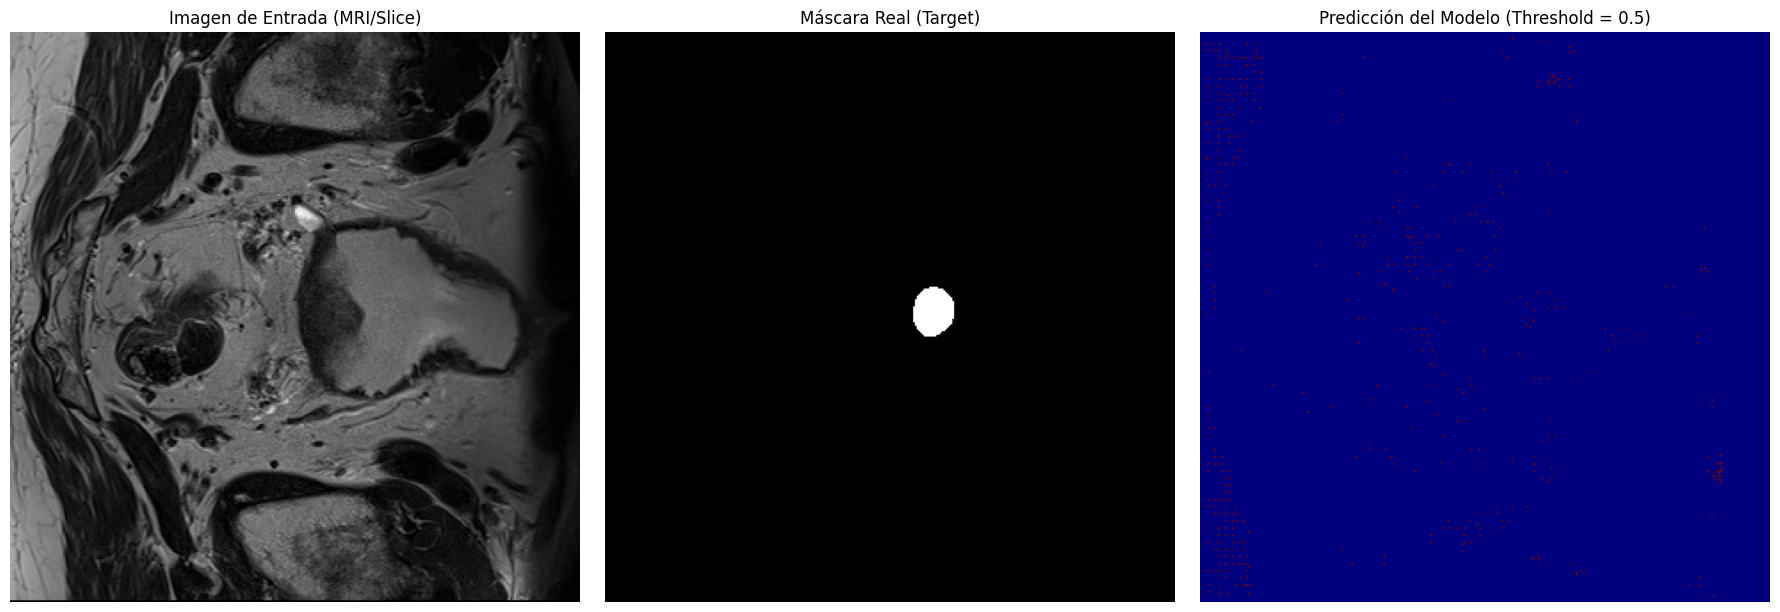

In [28]:
inferir_y_graficar(prostate_train_loader, metanca_model, device=device, batch_idx=0)

In [ ]:
## probaremos un entrenamiento aplicando el meta nca

In [26]:
## Pool de entrenamiento para estabilidad de los NCA
class NCAPool:
    '''pool de estados latentes para la estabilidad de los NCA'''
    def __init__(self, pool_size, channels, h, w, device, CHANNELS_LEVEL_1 = CHANNELS_LEVEL_1):
        # El pool guarda el estado latente completo (N, C, H, W) 
        self.size = pool_size
        self.pool = torch.zeros(pool_size, channels, h, w).to(device)
        self.device = device

        ## guardamos la salida original del encoder
        self.pool_base = torch.zeros(pool_size, channels, h, w, device=device)

        ## guarda las mascaras correspondientes al estado latente
        self.pool_masks = torch.zeros(pool_size, 4*h, 4*w, dtype=torch.float32, device=device)

        ## guarda el c1
        self.pool_c1 = torch.zeros(pool_size, CHANNELS_LEVEL_1 , 4*h, 4*w, device=device)

    def sample(self, batch_size, current_latent, current_c1, current_masks):
        '''muestrea elemetos del pool de forma estocastica (95% viejos, 5% nuevos/reset)'''
        ## Seleccionamos índices al azar del pool
        idx = torch.randint(0, self.size, (batch_size,), device=self.device)

        ## copiamos lo estados guardados en esos indices
        sampled_states = self.pool[idx].clone()
        sampled_bases = self.pool_base[idx].clone()
        sampled_masks = self.pool_masks[idx].clone()
        sampled_c1 = self.pool_c1[idx].clone()

        # Detectar qué elementos muestreados están completamente vacíos (en ceros)
        # Calculamos la suma absoluta a lo largo de las dimensiones de Canales, Alto y Ancho 
        # Si la suma es 0, el tensor está vacío.
        es_cero = (sampled_states.abs().sum(dim=[1, 2, 3]) == 0.0).float()
        # Reshapeamos a [B, 1, 1, 1] para poder multiplicar por los tensores latentes
        es_cero_mask = es_cero.view(batch_size, 1, 1, 1)
        ## 5 % prob de reserear la salida del encoder
        reset_mask = (torch.rand(batch_size, 1, 1, 1, device=self.device) < 0.05).float()

        # COMBINACIÓN DE MÁSCARAS:
        # Queremos forzar el uso de `current_latent` SI la máscara estocástica se activa 
        # O SI la ranura del pool está completamente vacía (es_cero_mask == 1).
        # Usamos la operación lógica OR mediante torch.max, o sumando y recortando en 1.0
        mascara_final_reset = torch.clamp(reset_mask + es_cero_mask, 0.0, 1.0)

        ## si reset_mask es 1 usamos el estado actual del encoder, si es 0 usamos el estado muestreado del pool
        x_input = current_latent * mascara_final_reset + sampled_states * (1.0 - mascara_final_reset)
        x_base = current_latent * mascara_final_reset + sampled_bases * (1.0 - mascara_final_reset)
        x_c1 = current_c1 * mascara_final_reset + sampled_c1 * (1.0 - mascara_final_reset)


        # Reshapeamos la máscara de reset para que se acople a las dimensiones (B, H, W) de las masks
        reset_mask_spatial = mascara_final_reset #.squeeze(1) # Pasa de (B, 1, 1, 1) a (B, 1, 1)

        # Le agregamos la dimensión de canales a sampled_masks para que sea [4, 1, 320, 320]
        sampled_masks_4d = sampled_masks.unsqueeze(1)
        
        x_masks = current_masks * reset_mask_spatial.long() + sampled_masks_4d * (1.0 - reset_mask_spatial).long()
        

        return x_input, x_base, x_c1, x_masks.squeeze(1), idx

    def update(self, idx, new_states, original_bases, original_c1, final_masks):
        # Guardamos los estados evolucionados de vuelta en el buffer, sin gradietes
        self.pool[idx] = new_states.detach()
        self.pool_base[idx] = original_bases.detach()
        self.pool_c1[idx] = original_c1.detach()
        self.pool_masks[idx] = final_masks.detach()


In [27]:
## antes hay que:
metanca_model = models.MetaNCASegmenter(ae_params=params_encoder, nca_steps=32).to(device)
metanca_model.ae.load_state_dict(ae_model.state_dict())  # Cargamos los pesos del autoencoder entrenado previamente


<All keys matched successfully>

In [30]:
'''Entrenamiento del metaNCA segmenter, fase 2, con autoencoder congelado'''
epochs = 1


## entrenamiento metaNCA segmenter
print(" Congelando parámetros del Autoencoder...")
for param in metanca_model.ae.parameters():
    param.requires_grad = False
    param.grad = None  # Forzamos la eliminación de cualquier gradiente residual de la Fase 1

# Aseguramos que el Predictor y el NCA sí calculen gradientes
for param in metanca_model.param_predictor.parameters():
    param.requires_grad = True
metanca_model.nca.leak_factor.requires_grad = True


# Pasamos única y exclusivamente los parámetros que requieren gradiente
# Esto evita que Adam aplique updates o momentum en los tensores congelados
optimizer = torch.optim.Adam([
    {'params': [p for p in metanca_model.nca.parameters() if p.requires_grad]},
    {'params': [p for p in metanca_model.param_predictor.parameters() if p.requires_grad]}
], lr=1e-4)

criterion1 = bce_loss
criterion2 = dice_loss
#criterion3 = SpatialContinuityLoss(alpha=1e-4) # Para fomentar la continuidad espacial en las predicciones

metanca_model.to(device)

metanca_model.train()  # Activa modo entrenamiento general para el predictor
metanca_model.ae.eval() # Fuerza al Autoencoder a mantenerse estático

# Blindaje extra: Reemplazamos temporalmente el método train del AE 
# para que ninguna llamada accidental en el loop altere sus sub-capas
def dezafectar_train(mode=True):
    for module in metanca_model.ae.modules():
        if isinstance(module, (nn.BatchNorm2d, nn.Dropout2d)):
            module.eval()
metanca_model.ae.train = dezafectar_train
dezafectar_train()


## inicializamos el pool latnete
pool_latente = NCAPool(pool_size=256, channels=CHANNELS_LATENT, h=80, w=80, device=device, CHANNELS_LEVEL_1=CHANNELS_LEVEL_1)
print(" Iniciando loop de prueba preliminar blindado...")

for epoch in range(epochs):
    total_loss = 0.0

    for i, (imgs, masks) in enumerate(prostate_train_loader):
        imgs, masks = imgs.to(device), masks.to(device)
        
        # set_to_none=True elimina los gradientes del optimizador liberando VRAM
        optimizer.zero_grad(set_to_none=True)
        
        # Obtenemos el latente base inicial y el embedding para los pesos dinámicos
        with torch.no_grad():
            c1_out = metanca_model.ae.conv_layer_1(imgs)
            c2_out = metanca_model.ae.conv_layer_2(c1_out)
            p1_out = metanca_model.ae.pass_through_1(imgs)
            p2_out = metanca_model.ae.pass_through_2(p1_out)

            sum_enc = c2_out + p2_out
            latent_base = metanca_model.ae.conv_layer_3(sum_enc)

        
        # MUESTREO DEL POOL
        # En lugar de usar siempre 'latent_base', dejamos que el pool decida estocásticamente
        latent_input, original_bases, original_c1, target_masks, pool_indices = pool_latente.sample(imgs.shape[0], latent_base, c1_out, masks)

        # Generamos los pesos dinámicos a partir del lote actual
        latent_vector_limpio = original_bases.mean(dim=[2, 3])  ## simulacion adn pr ahora
        dynamic_weights = metanca_model.param_predictor(latent_vector_limpio)
        
        
        # El NCA evoluciona el estado seleccionado (ya sea inicial o intermedio del pool)
        ## ocupamos pasos aleatorios

        if epoch <= 3:
            pasos_tensor = torch.randint(low=8, high=16 + 1, size=(1,))
            steps_nca = pasos_tensor.item()
        else:
            pasos_tensor = torch.randint(low=8, high=32 + 1, size=(1,))
            steps_nca = pasos_tensor.item()

        latent_evolved = metanca_model.nca(latent_input, weights=dynamic_weights, steps=steps_nca)
        
        # ACTUALIZACIÓN DEL POOL
        # Guardamos los estados resultantes en el pool para la siguiente oportunidad
        pool_latente.update(pool_indices, latent_evolved, original_bases, original_c1, target_masks)

        
        # DECODER FINAL Y PÉRDIDA
        # El decoder toma los estados evolucionados para proyectar a la máscara final
        d3_out = metanca_model.ae.trans_conv_3(latent_evolved)
        d2_out = metanca_model.ae.trans_conv_2(d3_out)

        sum_dec = d2_out + original_c1  # Inyección del skip connection original

        mixed = metanca_model.ae.mix_layer(sum_dec)
        outputs = metanca_model.ae.trans_conv_1(mixed)

        target_masks = target_masks.unsqueeze(1).float()  # Aseguramos que tenga la dimensión de canal
        
        ## optimizacion clasica
        # Suma de las 3 losses: Píxel (CE) + Región (Dice) + Suavizado (TV)
        loss_ce = criterion1(outputs, target_masks)
        loss_dice = criterion2(outputs, target_masks)
        #loss_tv = criterion3(outputs)

        loss = loss_ce + loss_dice #+ loss_tv

        loss.backward()

        # Escudo anti-explosión final
        #torch.nn.utils.clip_grad_norm_(filter(lambda p: p.requires_grad, metanca_model.parameters()), max_norm=1.0)

        optimizer.step()
        
        # Restricción matemática de estabilidad del autómata celular
        with torch.no_grad():
            metanca_model.nca.leak_factor.clamp_(1e-3, 1e-1)
        
        total_loss += loss.item()

        if (i + 1) % 10 == 0:
            print(f"\n✅ Van {i + 1} batches procesados exitosamente.")
            print(f"📊 Loss promedio actual: {total_loss / (i + 1):.4f}")
            print(f"💧 Leak Factor actual: {metanca_model.nca.leak_factor.item():.4f}")

    print(f"\n🎯 Época [{epoch+1}/{epochs}] - Loss promedio: {total_loss / len(prostate_train_loader):.4f}")
        
        
# lo guardamos al final
#torch.save(metanca_model.state_dict(), "meta_nca2.pth")


 Congelando parámetros del Autoencoder...
 Iniciando loop de prueba preliminar blindado...

✅ Van 10 batches procesados exitosamente.
📊 Loss promedio actual: 0.9971
💧 Leak Factor actual: 0.1000

✅ Van 20 batches procesados exitosamente.
📊 Loss promedio actual: 0.9849
💧 Leak Factor actual: 0.1000

✅ Van 30 batches procesados exitosamente.
📊 Loss promedio actual: 0.9689
💧 Leak Factor actual: 0.1000

✅ Van 40 batches procesados exitosamente.
📊 Loss promedio actual: 0.9630
💧 Leak Factor actual: 0.1000

✅ Van 50 batches procesados exitosamente.
📊 Loss promedio actual: 0.9580
💧 Leak Factor actual: 0.1000

✅ Van 60 batches procesados exitosamente.
📊 Loss promedio actual: 0.9508
💧 Leak Factor actual: 0.1000

✅ Van 70 batches procesados exitosamente.
📊 Loss promedio actual: 0.9454
💧 Leak Factor actual: 0.1000

✅ Van 80 batches procesados exitosamente.
📊 Loss promedio actual: 0.9408
💧 Leak Factor actual: 0.1000

✅ Van 90 batches procesados exitosamente.
📊 Loss promedio actual: 0.9335
💧 Leak Fact

In [31]:
imgs, masks = next(iter(prostate_train_loader))

imgs, masks = imgs.to(device), masks.to(device)

with torch.no_grad():
    c1_out = metanca_model.ae.conv_layer_1(imgs)
    c2_out = metanca_model.ae.conv_layer_2(c1_out)
    p1_out = metanca_model.ae.pass_through_1(imgs)
    p2_out = metanca_model.ae.pass_through_2(p1_out)

    sum_enc = c2_out + p2_out
    latent_base = metanca_model.ae.conv_layer_3(sum_enc)

In [32]:
# MUESTREO DEL POOL
# En lugar de usar siempre 'latent_base', dejamos que el pool decida estocásticamente
latent_input, original_bases, original_c1, target_masks, pool_indices = pool_latente.sample(imgs.shape[0], latent_base, c1_out, masks)

# Generamos los pesos dinámicos a partir del lote actual
latent_vector_limpio = original_bases.mean(dim=[2, 3])  ## simulacion adn pr ahora
dynamic_weights = metanca_model.param_predictor(latent_vector_limpio)


# El NCA evoluciona el estado seleccionado (ya sea inicial o intermedio del pool)
## ocupamos pasos aleatorios

pasos_tensor = torch.randint(low=8, high=16 + 1, size=(1,))
steps_nca = pasos_tensor.item()

latent_evolved = metanca_model.nca(latent_input, weights=dynamic_weights, steps=steps_nca)

In [24]:
imgs, masks = next(iter(prostate_train_loader))

In [36]:
target_masks.unsqueeze(1).shape

torch.Size([4, 1, 320, 320])

In [84]:
pool_latente.pool_masks.dtype

torch.int64

In [63]:
pool_latente.pool_masks[[0,1,2,4]].shape

torch.Size([4, 320, 320])

In [39]:
target_masks.shape

torch.Size([4, 4, 320, 320])

In [33]:
masks.shape

torch.Size([4, 1, 320, 320])

In [34]:
latent_base.shape

torch.Size([4, 32, 80, 80])

In [35]:
masks.shape

torch.Size([4, 1, 320, 320])

In [85]:
torch.zeros(10, 80, 80, dtype=torch.long).dtype

torch.int64